# Research Question

To what extent have changes in modern pitching affected batting average and offensive production in Major League Baseball from 2000 to 2025?

# Introduction

This project shows the relationship between changes in modern MLB pitching and offensive production from 2000 through 2025. In particular, the analysis focuses on changes in pitching strikeout rate and four-seam fastball velocity and whether these changes are associated with batting average and OPS. I expect that increases in strikeout rate and fastball velocity will be associated with lower batting average and offensive production.

# 2. Data Sources

MLB Stats API
- AVG
- OBP
- SLG
- OPS 
- K%
- K/9

Baseball Savant
- Average fastball velocity

Statistics
- Traditional : 2000-2025
- Fastball Velocity : 2008-2025

 Reason for 2008 is because that year began league wide pitch-tracking era

In [1]:
import statsapi
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
hitting_data = []

for year in range(2000, 2026):
    
    data = statsapi.get(
        'stats',
        {
            'stats': 'season',
            'group': 'hitting',
            'season': year,
            'sportIds': 1,
            'playerPool': 'ALL',
            'limit': 5000
        }
    )
    
    hitting_data.append({
        'Year': year,
        'Data': data
    })

# Collecting Hitting Data

In [7]:
hitting_summary = []

for season_data in hitting_data:
    year = season_data["Year"]
    data = season_data["Data"]

    players = data["stats"][0]["splits"]

    hits = sum(player["stat"].get("hits", 0) for player in players)
    at_bats = sum(player["stat"].get("atBats", 0) for player in players)
    walks = sum(player["stat"].get("baseOnBalls", 0) for player in players)
    hbp = sum(player["stat"].get("hitByPitch", 0) for player in players)
    sac_flies = sum(player["stat"].get("sacFlies", 0) for player in players)
    total_bases = sum(player["stat"].get("totalBases", 0) for player in players)

    avg = hits / at_bats if at_bats else 0
    obp = (hits + walks + hbp) / (at_bats + walks + hbp + sac_flies) if (at_bats + walks + hbp + sac_flies) else 0
    slg = total_bases / at_bats if at_bats else 0
    ops = obp + slg

    hitting_summary.append({
        "Year": year,
        "AVG": avg,
        "OBP": obp,
        "SLG": slg,
        "OPS": ops
    })

hitting_df = pd.DataFrame(hitting_summary)
hitting_df.head()




,Year,AVG,OBP,SLG,OPS
0,2000,0.270464,0.344916,0.437145,0.782061
1,2001,0.263959,0.332202,0.426640,0.758842
2,2002,0.261333,0.331205,0.416658,0.747863
3,2003,0.264230,0.332569,0.422060,0.754629
4,2004,0.266036,0.335107,0.427778,0.762886


In [8]:
hitting_df.isnull().sum()

Year    0
AVG     0
OBP     0
SLG     0
OPS     0
dtype: int64

# Collecting Pitching Data

In [21]:
pitching_data = []

for year in range(2000, 2026):
    data = statsapi.get(
        'stats',
        {
            'stats': 'season',
            'group': 'pitching',
            'season': year,
            'sportIds': 1,
            'playerPool': 'ALL',
            'limit': 5000
        }
    )
    
    pitching_data.append({
        'Year': year,
        'Data': data['stats'][0]['splits']
    })

In [22]:
len(pitching_data)

26

In [23]:
pitching_data[0]['Year']

2000

In [24]:
len(pitching_data[0]['Data'])

606

# Calculate Pitching Stats 

In [26]:
pitching_summary = []

for season_data in pitching_data:
    year = season_data['Year']
    
    strikeouts = sum(
        player['stat'].get('strikeOuts', 0)
        for player in season_data['Data']
    )
    
    batters_faced = sum(
        player['stat'].get('battersFaced', 0)
        for player in season_data['Data']
    )
    
    total_outs = 0
    
    for player in season_data['Data']:
        innings = str(player['stat'].get('inningsPitched', '0.0'))
        whole, outs = innings.split('.')
        
        total_outs += int(whole) * 3
        total_outs += int(outs)
    
    total_innings = total_outs / 3
    
    k_percentage = (strikeouts / batters_faced) * 100
    k_per_9 = (strikeouts / total_innings) * 9
    
    pitching_summary.append({
        'Year': year,
        'K%': k_percentage,
        'K/9': k_per_9
    })

pitching_df = pd.DataFrame(pitching_summary)

In [31]:
pitching_df.style.format({
    'K%': '{:.2f}',
    'K/9': '{:.2f}'
})

,Year,K%,K/9
0,2000,16.48,6.53
1,2001,17.33,6.74
2,2002,16.82,6.53
3,2003,16.43,6.40
4,2004,16.88,6.60
5,2005,16.45,6.38
6,2006,16.83,6.59
7,2007,17.07,6.67
8,2008,17.53,6.83
9,2009,17.96,6.99


# Combine Hitting and Pitching Data

In [32]:

mlb_df = pd.merge(
    hitting_df,
    pitching_df,
    on='Year',
    how='inner'
)

mlb_df.head()

,Year,AVG,OBP,SLG,OPS,K%,K/9
0,2000,0.270464,0.344916,0.437145,0.782061,16.480519,6.525803
1,2001,0.263959,0.332202,0.426640,0.758842,17.330566,6.737213
2,2002,0.261333,0.331205,0.416658,0.747863,16.822871,6.529987
3,2003,0.264230,0.332569,0.422060,0.754629,16.431669,6.396836
4,2004,0.266036,0.335107,0.427778,0.762886,16.881388,6.601189


# Four-Seam Fastball Velocity

In [35]:
velocity_data = {
    'Year': [
        2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016,
        2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025
    ],
    'Fastball_Velocity': [
        91.1, 91.4, 91.4, 91.7, 91.8, 92.0, 92.0, 92.4, 92.6,
        92.4, 92.4, 92.6, 92.5, 92.9, 93.1, 93.2, 93.3, 93.6
    ]
}

velocity_df = pd.DataFrame(velocity_data)

velocity_df.head()

,Year,Fastball_Velocity
0,2008,91.1
1,2009,91.4
2,2010,91.4
3,2011,91.7
4,2012,91.8


#  Combine Hitting, Pitching, and Velocity Data

In [38]:
mlb_velocity_df = pd.merge(
    mlb_df,
    velocity_df,
    on='Year',
    how='inner'
)

mlb_velocity_df.head()

,Year,AVG,OBP,SLG,OPS,K%,K/9,Fastball_Velocity
0,2008,0.263757,0.333074,0.416234,0.749307,17.525889,6.825921,91.1
1,2009,0.262431,0.332932,0.417760,0.750692,17.955516,6.986481,91.4
2,2010,0.257352,0.325474,0.402841,0.728315,18.488518,7.129699,91.4
3,2011,0.255074,0.320559,0.399010,0.719570,18.617507,7.130968,91.7
4,2012,0.254540,0.318956,0.405323,0.724279,19.777499,7.561561,91.8


In [39]:
mlb_velocity_df.to_csv("mlb_final_dataset.csv", index=False)

# Exploratory Analysis

In [40]:
mlb_velocity_df.head()

,Year,AVG,OBP,SLG,OPS,K%,K/9,Fastball_Velocity
0,2008,0.263757,0.333074,0.416234,0.749307,17.525889,6.825921,91.1
1,2009,0.262431,0.332932,0.417760,0.750692,17.955516,6.986481,91.4
2,2010,0.257352,0.325474,0.402841,0.728315,18.488518,7.129699,91.4
3,2011,0.255074,0.320559,0.399010,0.719570,18.617507,7.130968,91.7
4,2012,0.254540,0.318956,0.405323,0.724279,19.777499,7.561561,91.8


In [41]:
mlb_velocity_df.describe()

,Year,AVG,OBP,SLG,OPS,K%,K/9,Fastball_Velocity
count,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000
mean,2016.500000,0.251710,0.320212,0.408704,0.728916,20.972773,8.048319,92.355556
std,5.338539,0.006315,0.006072,0.011932,0.016361,1.915934,0.725129,0.708953
min,2008.000000,0.242706,0.311546,0.386368,0.700052,17.525889,6.825921,91.100000
25%,2012.250000,0.245921,0.316865,0.400125,0.719112,19.797343,7.563294,91.850000
50%,2016.500000,0.252862,0.319546,0.407371,0.727713,21.381312,8.222650,92.400000
75%,2020.750000,0.255048,0.322479,0.417112,0.739386,22.539449,8.581458,92.825000
max,2025.000000,0.263757,0.333074,0.434849,0.757544,23.435480,9.068267,93.600000


In [42]:
mlb_velocity_df.iloc[[0, -1]]

,Year,AVG,OBP,SLG,OPS,K%,K/9,Fastball_Velocity
0,2008,0.263757,0.333074,0.416234,0.749307,17.525889,6.825921,91.1
17,2025,0.245246,0.315150,0.403809,0.718960,22.219367,8.492281,93.6


In [43]:
velocity_change = (
    mlb_velocity_df.loc[
        mlb_velocity_df['Year'] == 2025, 'Fastball_Velocity'
    ].iloc[0]
    -
    mlb_velocity_df.loc[
        mlb_velocity_df['Year'] == 2008, 'Fastball_Velocity'
    ].iloc[0]
)

k_change = (
    mlb_velocity_df.loc[
        mlb_velocity_df['Year'] == 2025, 'K%'
    ].iloc[0]
    -
    mlb_velocity_df.loc[
        mlb_velocity_df['Year'] == 2008, 'K%'
    ].iloc[0]
)

avg_change = (
    mlb_velocity_df.loc[
        mlb_velocity_df['Year'] == 2025, 'AVG'
    ].iloc[0]
    -
    mlb_velocity_df.loc[
        mlb_velocity_df['Year'] == 2008, 'AVG'
    ].iloc[0]
)

ops_change = (
    mlb_velocity_df.loc[
        mlb_velocity_df['Year'] == 2025, 'OPS'
    ].iloc[0]
    -
    mlb_velocity_df.loc[
        mlb_velocity_df['Year'] == 2008, 'OPS'
    ].iloc[0]
)

print(f"Fastball velocity change: {velocity_change:.2f} MPH")
print(f"K% change: {k_change:.2f} percentage points")
print(f"AVG change: {avg_change:.3f}")
print(f"OPS change: {ops_change:.3f}")

Fastball velocity change: 2.50 MPH
K% change: 4.69 percentage points
AVG change: -0.019
OPS change: -0.030


In [44]:
mlb_velocity_df[['Year', 'Fastball_Velocity', 'K%', 'AVG', 'OPS']]

,Year,Fastball_Velocity,K%,AVG,OPS
0,2008,91.1,17.525889,0.263757,0.749307
1,2009,91.4,17.955516,0.262431,0.750692
2,2010,91.4,18.488518,0.257352,0.728315
3,2011,91.7,18.617507,0.255074,0.719570
4,2012,91.8,19.777499,0.254540,0.724279
5,2013,92.0,19.856875,0.253465,0.714074
6,2014,92.0,20.356224,0.251156,0.700052
7,2015,92.4,20.392315,0.254435,0.721370
8,2016,92.6,21.119298,0.255350,0.738988
9,2017,92.4,21.643326,0.254972,0.750374


# Visualization 1: Strikeout Rate and Batting Average Over Time

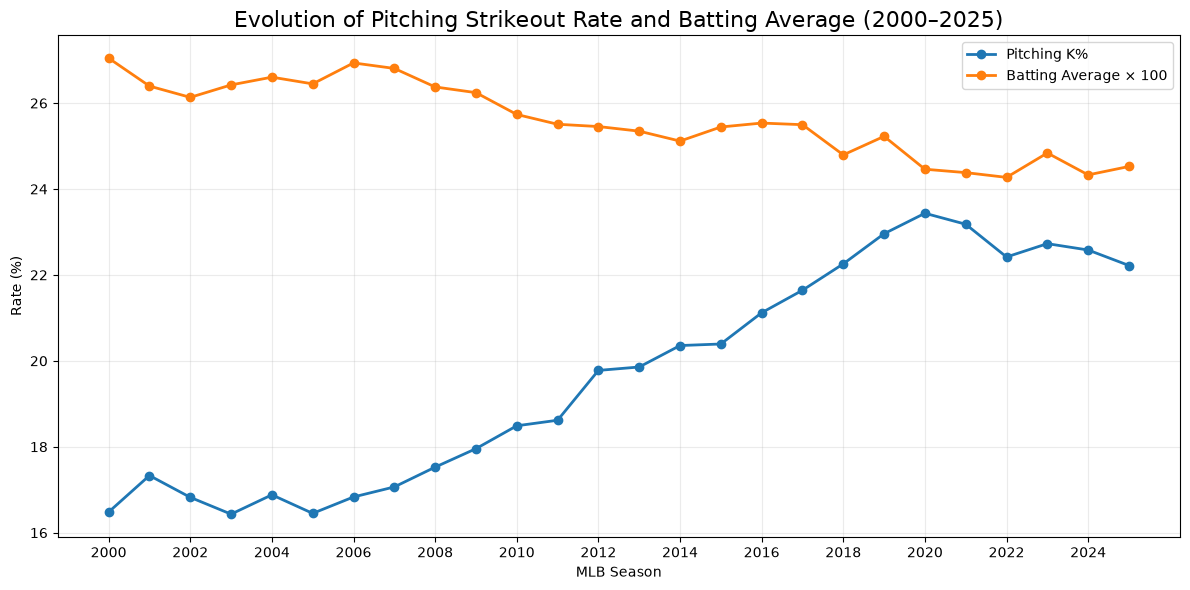

In [45]:
plt.figure(figsize=(12, 6))

plt.plot(
    mlb_df['Year'],
    mlb_df['K%'],
    marker='o',
    linewidth=2,
    label='Pitching K%'
)

plt.plot(
    mlb_df['Year'],
    mlb_df['AVG'] * 100,
    marker='o',
    linewidth=2,
    label='Batting Average × 100'
)

plt.title(
    'Evolution of Pitching Strikeout Rate and Batting Average (2000–2025)',
    fontsize=16
)

plt.xlabel('MLB Season')
plt.ylabel('Rate (%)')
plt.xticks(mlb_df['Year'][::2])
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

Visualization Description

The visualization shows an overall increase in pitching strikeout rate from 2000 to 2025, while batting average generally remained lower over the later portion of the period. This pattern showss that the rise in strikeout frequency corresponded with a decline in batting average. However, the visualization alone cannot establish a causal relationship because other factors may have influenced offensive performance.

# Visualization 2: Four-Seam Fastball Velocity and OPS

In [46]:
import numpy as np

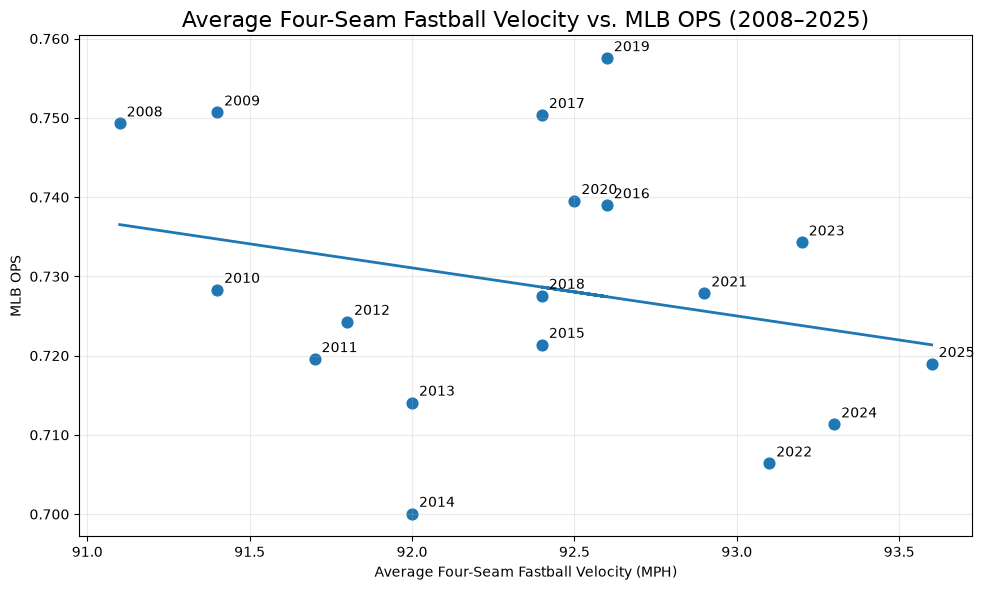

In [47]:
plt.figure(figsize=(10, 6))

x = mlb_velocity_df['Fastball_Velocity']
y = mlb_velocity_df['OPS']

plt.scatter(x, y, s=60)

# Add trend line
z = np.polyfit(x, y, 1)
trendline = np.poly1d(z)

plt.plot(
    x,
    trendline(x),
    linewidth=2
)

# Add year labels
for _, row in mlb_velocity_df.iterrows():
    plt.annotate(
        str(int(row['Year'])),
        (row['Fastball_Velocity'], row['OPS']),
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.title(
    'Average Four-Seam Fastball Velocity vs. MLB OPS (2008–2025)',
    fontsize=16
)

plt.xlabel('Average Four-Seam Fastball Velocity (MPH)')
plt.ylabel('MLB OPS')

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f'{x:.3f}')
)

plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

Visualization Description

The scatter plot shows the relationship between average four-seam fastball velocity and MLB OPS across seasons from 2008 through 2025. The trend line indicates the overall direction of the relationship. While the visualization can identify an association between the variables, it does not establish that changes in fastball velocity caused changes in offensive production.

# Correlation Analysis

In [48]:
velocity_ops_corr = mlb_velocity_df['Fastball_Velocity'].corr(
    mlb_velocity_df['OPS']
)

k_avg_corr = mlb_df['K%'].corr(
    mlb_df['AVG']
)

k_ops_corr = mlb_df['K%'].corr(
    mlb_df['OPS']
)

print(f"Correlation between fastball velocity and OPS: {velocity_ops_corr:.3f}")
print(f"Correlation between K% and batting average: {k_avg_corr:.3f}")
print(f"Correlation between K% and OPS: {k_ops_corr:.3f}")

Correlation between fastball velocity and OPS: -0.263
Correlation between K% and batting average: -0.932
Correlation between K% and OPS: -0.581


Correlation Findings

The correlation analysis indicates that pitching strikeout rate has a stronger relationship with offensive performance than four-seam fastball velocity. The correlation between four-seam fastball velocity and OPS was -0.263, indicating a weak negative relationship. In comparison, pitching K% had a very strong negative correlation with batting average (r = -0.932) and a moderate negative correlation with OPS (r = -0.581).

These results suggest that increases in strikeout rate were more closely associated with declines in offensive production than increases in four-seam fastball velocity. However, these correlations do not establish causation. Other factors, including changes in hitter strategy, pitch selection, league rules, ball composition, and overall baseball strategy, may have contributed to these relationships.

# Key Findings

The analysis produced several key findings regarding the relationship between modern pitching and offensive production in MLB.

1. **Four-seam fastball velocity increased over time.** Average four-seam fastball velocity increased by 2.50 MPH between 2008 and 2025, from 91.1 MPH to 93.6 MPH.

2. **Strikeout rate increased substantially.** Pitching K% increased by 4.69 percentage points between 2008 and 2025.

3. **Batting average declined.** MLB batting average decreased by 0.019 between 2008 and 2025.

4. **OPS also declined slightly.** MLB OPS decreased by 0.030 between 2008 and 2025.

5. **Strikeout rate had a stronger relationship with offensive production than fastball velocity.** The correlation between four-seam fastball velocity and OPS was -0.263, indicating a weak negative relationship. In comparison, K% had a very strong negative correlation with batting average (r = -0.932) and a moderate negative correlation with OPS (r = -0.581).

Overall, the findings suggest that increases in strikeout rate were more closely associated with declines in offensive production than increases in four-seam fastball velocity alone. However, these results demonstrate association rather than causation.

# Conclusion

This analysis examined the extent to which changes in modern pitching, particularly four-seam fastball velocity and strikeout rate, were associated with changes in batting average and offensive production in Major League Baseball from 2000 to 2025. The results show that pitching became both faster and more strikeout-oriented over the period examined. From 2008 to 2025, average four-seam fastball velocity increased by 2.50 MPH, while pitching K% increased by 4.69 percentage points. Over the same period, batting average decreased by 0.019 and OPS decreased by 0.030.

However, the correlation results suggest that fastball velocity alone was not strongly associated with offensive production. The correlation between four-seam fastball velocity and OPS was -0.263, representing a weak negative relationship. In contrast, pitching K% had a much stronger relationship with offensive outcomes, with a correlation of -0.932 with batting average and -0.581 with OPS.

Overall, the findings suggest that the rise in strikeout rate was more closely associated with declines in offensive production than the increase in four-seam fastball velocity alone. This indicates that the evolution of MLB pitching cannot be explained simply by pitchers throwing harder. Changes in pitching strategy, pitch selection, hitter approach, and other factors may also contribute to changes in offensive performance. Because this study uses observational, league-level data, the results should be interpreted as relationships rather than evidence of causation.

The analysis provides evidence that modern pitching has changed considerably over the past two decades and that the increasing prevalence of strikeouts is closely associated with changes in MLB offense. Future research could examine additional variables, such as breaking-ball usage, pitch movement, launch angle, exit velocity, or changes in MLB rules, to better understand the factors driving the evolution of hitting and pitching.

# Conceptualization and Operationalization

## Conceptualization

This project examines how changes in modern MLB pitching relate to league-wide batting average and offensive production. The main pitching concepts are strikeout frequency and fastball velocity. Offensive production is represented by batting average (AVG), on-base percentage (OBP), slugging percentage (SLG), and on-base plus slugging (OPS).

The unit of analysis is the **MLB league season**. This means each observation represents one MLB season rather than an individual player. The traditional statistics cover 2000–2025, while fastball velocity is analyzed from 2008–2025 because league-wide pitch-tracking data became available beginning in 2008.

## Operationalization

- **AVG:** Hits divided by at-bats.
- **OBP:** (Hits + walks + hit by pitch) divided by (at-bats + walks + hit by pitch + sacrifice flies).
- **SLG:** Total bases divided by at-bats.
- **OPS:** OBP + SLG.
- **K%:** Strikeouts divided by batters faced, multiplied by 100.
- **K/9:** Strikeouts per nine innings.
- **Average four-seam fastball velocity:** League-season average four-seam fastball velocity measured in miles per hour.

The primary comparison examines whether increases in pitching strikeout rate and fastball velocity are associated with decreases in batting average and OPS. Because the data are observational and aggregated at the league-season level, the analysis identifies associations rather than causal effects.


# Data Cleaning and Preparation

The data were collected from the MLB Stats API using the `MLB-StatsAPI` Python package and combined with league-level fastball velocity data from Baseball Savant.

The MLB Stats API data were collected for each season from 2000 through 2025. Hitting statistics were aggregated across the player-level season records to calculate league-season AVG, OBP, SLG, and OPS. Pitching statistics were similarly aggregated to calculate league-season K% and K/9.

For innings pitched, MLB's baseball notation was converted into total outs before calculating total innings. This prevents values such as `5.2` from being incorrectly treated as 5.2 decimal innings; `5.2` represents five innings and two outs.

The velocity dataset was then merged with the traditional statistics using `Year` as the common key. Because league-wide pitch tracking begins in 2008, the velocity analysis uses 2008–2025.

Missing-value checks were performed after constructing the summary datasets. The final variables used in the analysis contain no missing values. The final merged velocity dataset contains 18 MLB seasons and 8 variables.


# Ethics and Limitations

This project uses publicly available MLB statistics and does not contain personally identifiable or sensitive information. The analysis is conducted at the league-season level, which also reduces the risk of making claims about individual players from aggregated data.

There are several limitations. First, the velocity analysis begins in 2008 because that is when league-wide pitch-tracking data became available, so velocity cannot be compared directly across the entire 2000–2025 period. Second, pitch-tracking technologies and measurement methods have changed over time. Third, the observational design means that correlation does not establish causation.

Other factors may influence offensive production, including hitter strategy, pitch selection, pitch movement, defensive positioning, rule changes, ball composition, and broader changes in MLB strategy. Therefore, the results should be interpreted as evidence of relationships between league-level trends rather than proof that one variable directly caused another.

Future research could incorporate pitch movement, breaking-ball usage, launch angle, exit velocity, and additional rule or strategic changes to provide a more complete explanation of offensive trends.


# Academic References

Mercier, M.-A., Tremblay, M., Daneau, C., & Descarreaux, M. (2020). Individual factors associated with baseball pitching performance: Scoping review. *BMJ Open Sport & Exercise Medicine, 6*(1), e000704. https://doi.org/10.1136/bmjsem-2019-000704

Slowik, J. S., Aune, K. T., Diffendaffer, A. Z., Cain, E. L., Dugas, J. R., & Fleisig, G. S. (2019). Fastball velocity and elbow-varus torque in professional baseball pitchers. *Journal of Athletic Training, 54*(3), 296–301. https://doi.org/10.4085/1062-6050-558-17

Manzi, J. E., Dowling, B., Wang, Z., Sudah, S. Y., Moran, J., Chen, F. R., Estrada, J. A., Nicholson, A., Ciccotti, M. G., Ruzbarsky, J. J., & Dines, J. S. (2024). Kinematic modeling of pitch velocity in high school and professional baseball pitchers: Comparisons with the literature. *Orthopaedic Journal of Sports Medicine, 12*(8). https://doi.org/10.1177/23259671241262730


# AI Usage Disclosure

Generative AI was used as a coding and writing support tool during project development. It was used to help troubleshoot Python/API errors, explain code logic, improve organization and wording, and suggest ways to communicate findings. The student reviewed the code, data calculations, visualizations, interpretations, and final written material before submission.
